In [4]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "nova-14.lyon.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

In [5]:
exp_q1 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 30, 10, 19, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 24, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 30, 10, 27, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 32, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 30, 10, 35, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 40, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 30, 10, 42, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 30, 10, 47, 0, tzinfo=local_tz)
    }
}

exp_q2 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 15, 0, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 5, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 15, 10, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 15, 30, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 15, 22, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 27, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 15, 34, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 15, 39, 0, tzinfo=local_tz)
    }
}
exp_q3 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 14, 49, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 52, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 14, 26, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 31, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 14, 34, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 39, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 14, 41, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 14, 46, 30, tzinfo=local_tz)
    }
}
exp_q5 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 28, 14, 49, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 14, 54, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 28, 14, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 2, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 28, 15, 5, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 10, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 28, 15, 12, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 17, 0, tzinfo=local_tz)
    }
}

exp_q8 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 10, 35, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 10, 40, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 10, 56, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 1, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 11, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 18, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 11, 33, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 38, 0, tzinfo=local_tz)
    }
}

exp_q11 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 11, 48, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 53, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 11, 57, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 12, 2, 30, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 12, 4, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 12, 9, 30, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 12, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 12, 18, 0, tzinfo=local_tz)
    }
}


In [6]:
metric_query = 'sum(rate(flink_taskmanager_job_task_operator_numRecordsOut{operator_name=~"Source:.*"}[1m]))'
step = "5s"
output_filename = 'exp2a_q1_tput.csv'

execute_query_range(exp_q1, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp2a_q1_tput.csv'


### BoxPlot

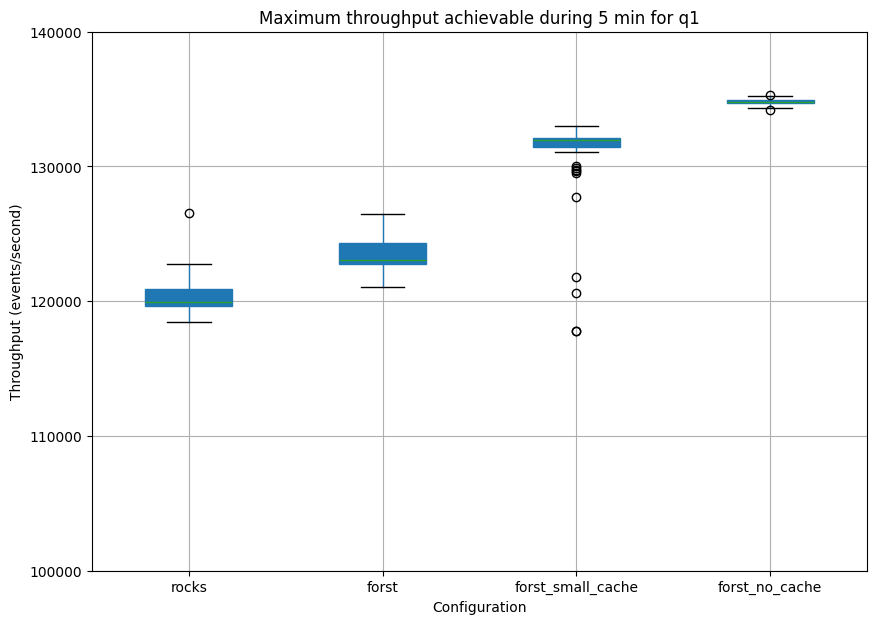

In [7]:
file_path = 'exp2a_q1_tput.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['rocks', 'forst', 'forst_small_cache', 'forst_no_cache']
    
    plt.figure(figsize=(10, 7))
    df.boxplot(grid=True, patch_artist=True)
    
    plt.title('Maximum throughput achievable during 5 min for q1')
    plt.ylabel('Throughput (events/second)')
    plt.xlabel('Configuration')
    plt.yticks(np.arange(100000, 150000, 10000))
    plt.savefig('boxplot_q1.png')
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

In [ ]:
import pandas as pd
import numpy as np
import os

def analyze_throughput(file_list):
    """
    Calcule et affiche la différence de throughput moyenne en pourcentage
    entre RocksDB et Forst à partir d'une liste de fichiers CSV.

    Args:
        file_list (list): Une liste de chemins vers les fichiers CSV à analyser.
    """
    rocksdb_means = []
    forst_means = []

    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"Attention : Le fichier {file_path} n'a pas été trouvé.")
            continue

        # Lire le fichier CSV.
        # Les noms de colonnes sont inférés comme 'Time', 'c1', 'c2', etc.
        df = pd.read_csv(file_path)
        df.columns = ['Time'] + [f'c{i+1}' for i in range(df.shape[1] - 1)]

        # Identifier les colonnes contenant des données de throughput
        data_cols = [col for col in df.columns if col != 'Time' and not df[col].isnull().all()]

        # On suppose que la première colonne de données est RocksDB et la seconde est Forst
        if len(data_cols) >= 2:
            rocksdb_col = data_cols[0]
            forst_col = data_cols[1]

            # Calculer la moyenne pour chaque backend en ignorant les valeurs vides
            rocksdb_mean = df[rocksdb_col].mean(skipna=True)
            forst_mean = df[forst_col].mean(skipna=True)

            rocksdb_means.append(rocksdb_mean)
            forst_means.append(forst_mean)
        else:
            print(f"Attention : Moins de deux colonnes de données trouvées dans {file_path}.")

    if not rocksdb_means or not forst_means:
        print("Aucune donnée n'a pu être traitée. Vérifiez vos fichiers.")
        return

    # Calculer le throughput moyen global
    overall_rocksdb_mean = np.mean(rocksdb_means)
    overall_forst_mean = np.mean(forst_means)

    # Calculer la différence en pourcentage
    percentage_difference = ((overall_forst_mean - overall_rocksdb_mean) / overall_rocksdb_mean) * 100

    # Afficher les résultats
    print("--- Résultats de l'analyse de throughput ---")
    print(f"Throughput moyen global pour RocksDB: {overall_rocksdb_mean:.2f}")
    print(f"Throughput moyen global pour Forst: {overall_forst_mean:.2f}")
    print(f"Différence moyenne en pourcentage (Forst vs RocksDB): {percentage_difference:.2f}%")
    print("-------------------------------------------")


# --- Utilisation du script ---
# 1. Assurez-vous que ce script est dans le même dossier que vos fichiers CSV.
# 2. Modifiez la liste 'files_to_analyze' pour inclure vos noms de fichiers.
files_to_analyze = [
    "exp2a_q1_tput.csv",
    "exp2a_q2_tput.csv"
]

# 3. Exécutez le script.
analyze_throughput(files_to_analyze)

--- Résultats de l'analyse de throughput ---
Throughput moyen global pour RocksDB: 146206.85
Throughput moyen global pour Forst: 133504.50
Différence moyenne en pourcentage (Forst vs RocksDB): -8.69%
-------------------------------------------


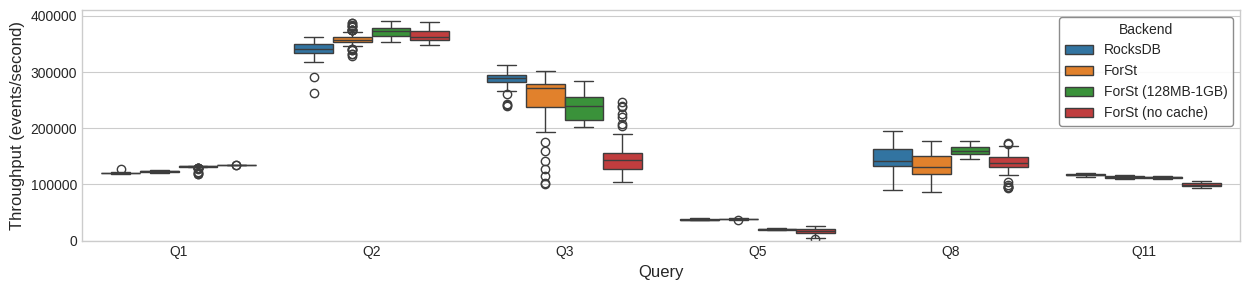

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

def plot_combined_boxplots_custom_names(file_list):
    """
    Crée un diagramme de boxplots groupés avec des noms de backend personnalisés.

    Args:
        file_list (list): Une liste de chemins vers les fichiers CSV à analyser.
    """
    all_data = []
    # Noms de colonnes personnalisés fournis par l'utilisateur
    custom_column_names = ['Time', 'RocksDB', 'ForSt', 'ForSt (128MB-1GB)', 'ForSt (no cache)']

    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"Attention : Le fichier {file_path} n'a pas été trouvé.")
            continue

        match = re.search(r'q(\d+)_tput\.csv', file_path)
        if not match:
            continue
        query_num = f"Q{match.group(1)}"

        df = pd.read_csv(file_path)
        
        # S'assurer que le DataFrame a le bon nombre de colonnes
        # avant de renommer pour éviter les erreurs.
        if df.shape[1] != len(custom_column_names):
             # Adapte le nombre de colonnes dans le cas où un fichier n'en aurait pas 5
             temp_cols = custom_column_names[:df.shape[1]]
             df.columns = temp_cols
        else:
            df.columns = custom_column_names
        
        # Itérer sur les noms de backend personnalisés (en ignorant 'Time')
        for col_name in df.columns:
            if col_name != 'Time' and not df[col_name].isnull().all():
                temp_df = pd.DataFrame({
                    'Throughput': df[col_name].dropna(),
                    'State Backend': col_name,  # Utilise le nom personnalisé
                    'Query': query_num
                })
                all_data.append(temp_df)

    if not all_data:
        print("Aucune donnée n'a pu être traitée. Vérifiez vos fichiers.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    query_order = sorted(combined_df['Query'].unique(), key=lambda q: int(q[1:]))

    # Création du graphique (identique à la version précédente)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 3))
    
    sns.boxplot(
        x='Query',
        y='Throughput',
        hue='State Backend',
        data=combined_df,
        order=query_order,
        ax=ax,
    )

    ax.set_xlabel('Query', fontsize=12)
    ax.set_ylabel('Throughput (events/second)', fontsize=12)
    ax.legend(title='Backend', loc='upper right',frameon=True,edgecolor='gray',facecolor='white',framealpha=0.9 )
    ax.set_ylim(0)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.savefig('max_tput_bplot.pdf')

# --- Utilisation du script ---
files_to_analyze = [ "exp2a_q3_tput.csv", "exp2a_q2_tput.csv", "exp2a_q1_tput.csv","exp2a_q11_tput.csv", "exp2a_q8_tput.csv", "exp2a_q5_tput.csv"] #    "exp2a_q3_tput.csv", "exp2a_q2_tput.csv", "exp2a_q1_tput.csv"


plot_combined_boxplots_custom_names(files_to_analyze)

La figure combinée a été sauvegardée sous 'figure_combinee.png'


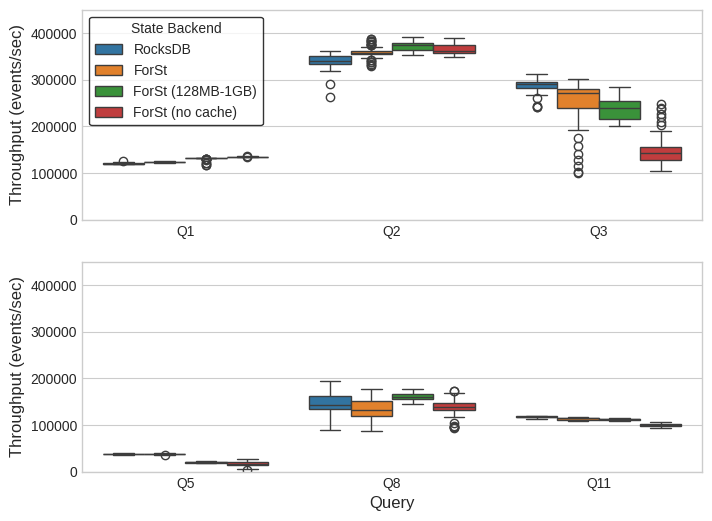

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

def draw_boxplots_on_axis(ax, file_list, show_legend=True):
    """
    Dessine les boxplots pour une liste de fichiers sur un axe matplotlib donné.
    """
    all_data = []
    custom_column_names = ['Time', 'RocksDB', 'ForSt', 'ForSt (128MB-1GB)', 'ForSt (no cache)']

    for file_path in file_list:
        if not os.path.exists(file_path):
            continue
        match = re.search(r'q(\d+)_tput\.csv', file_path)
        if not match:
            continue
        query_num = f"Q{match.group(1)}"
        df = pd.read_csv(file_path)
        
        # Adapte les noms de colonnes au nombre réel de colonnes
        current_cols = custom_column_names[:df.shape[1]]
        df.columns = current_cols
        
        for col_name in current_cols:
            if col_name != 'Time' and not df[col_name].isnull().all():
                temp_df = pd.DataFrame({
                    'Throughput': df[col_name].dropna(),
                    'State Backend': col_name,
                    'Query': query_num
                })
                all_data.append(temp_df)

    if not all_data:
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    query_order = sorted(combined_df['Query'].unique(), key=lambda q: int(q[1:]))

    sns.boxplot(
        x='Query',
        y='Throughput',
        hue='State Backend',
        data=combined_df,
        order=query_order,
        ax=ax
    )
    
    # Gérer la légende
    if show_legend:
        # Déplacer la légende à l'extérieur
        ax.legend(title='State Backend',loc='upper left',frameon=True,facecolor='white',edgecolor='black',framealpha=0.8)
    else:
        ax.get_legend().remove() # Retirer la légende pour éviter les doublons
    ax.set_ylim(0,450000)
    ax.set_xlabel('') # On mettra un label commun
    ax.set_ylabel('Throughput (events/sec)',fontsize=12)
    # Formater l'axe Y pour une meilleure lisibilité

# --- Script principal pour créer la figure combinée ---

# 1. Définir les listes de fichiers pour chaque graphique
files_for_bottom_plot = ["exp2a_q11_tput.csv", "exp2a_q8_tput.csv", "exp2a_q5_tput.csv"]
files_for_top_plot = ["exp2a_q3_tput.csv", "exp2a_q2_tput.csv", "exp2a_q1_tput.csv"]

# 2. Créer une figure avec 2 sous-graphiques (2 lignes, 1 colonne)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# 3. Dessiner le premier graphique sur le premier axe (ax1)
draw_boxplots_on_axis(ax1, files_for_top_plot, show_legend=True)

# 4. Dessiner le second graphique sur le second axe (ax2)
draw_boxplots_on_axis(ax2, files_for_bottom_plot, show_legend=False) # Pas besoin de répéter la légende
ax2.set_xlabel('Query', fontsize=12) # Label X uniquement pour le graphique du bas

# 5. Ajuster l'espacement et sauvegarder
plt.savefig('max_tput_bplot.pdf', dpi=150)

print("La figure combinée a été sauvegardée sous 'figure_combinee.png'")